# Lab 3 Variant 6

- FIR: `b = [0.25, 0.25, 0.25, 0.25]`
- IIR: `b = [1, 1, 1]`, `a = [1, -0.5]`
- Adaptive LMS: `mu = 0.1`, `M = 6`


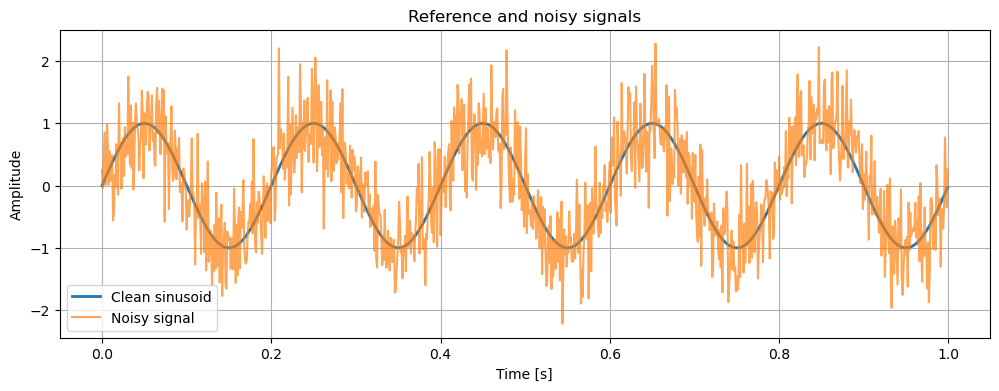

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Shared test signal (clean sinusoid + noise)
fs = 1000
T = 1.0
t = np.arange(0, T, 1/fs)
f0 = 5
clean = np.sin(2 * np.pi * f0 * t)
noise = 0.5 * np.random.randn(len(t))
noisy = clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t, clean, label='Clean sinusoid', linewidth=2)
plt.plot(t, noisy, label='Noisy signal', alpha=0.7)
plt.title('Reference and noisy signals')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()


## 1) FIR Filter
Coefficients: `b = [0.25, 0.25, 0.25, 0.25]`


In [14]:
def fir_filter(x, b):
    b = np.asarray(b, dtype=float)
    M = len(b)
    y = np.zeros(len(x), dtype=float)
    for n in range(len(x)):
        acc = 0.0
        for k in range(M):
            if n - k >= 0:
                acc += b[k] * x[n - k]
        y[n] = acc
    return y

b_fir = [0.25, 0.25, 0.25, 0.25]
y_fir = fir_filter(noisy, b_fir)


## 2) IIR Filter
Coefficients: `b = [1, 1, 1]`, `a = [1, -0.5]`


In [15]:
def iir_filter(x, b, a):
    b = np.asarray(b, dtype=float)
    a = np.asarray(a, dtype=float)
    if a[0] != 1.0:
        b = b / a[0]
        a = a / a[0]

    y = np.zeros(len(x), dtype=float)
    M = len(b)
    N = len(a)

    for n in range(len(x)):
        ff = 0.0
        for k in range(M):
            if n - k >= 0:
                ff += b[k] * x[n - k]

        fb = 0.0
        for k in range(1, N):
            if n - k >= 0:
                fb += a[k] * y[n - k]

        y[n] = ff - fb
    return y

b_iir = [1, 1, 1]
a_iir = [1, -0.5]
y_iir = iir_filter(noisy, b_iir, a_iir)


## 3) Adaptive LMS Filter
Parameters: `mu = 0.1`, `M = 6`


In [16]:
def lms_filter(x, d, mu, M):
    x = np.asarray(x, dtype=float)
    d = np.asarray(d, dtype=float)

    n_samples = len(x)
    w = np.zeros(M, dtype=float)
    y = np.zeros(n_samples, dtype=float)
    e = np.zeros(n_samples, dtype=float)

    for n in range(M, n_samples):
        x_vec = x[n-M:n][::-1]
        y[n] = np.dot(w, x_vec)
        e[n] = d[n] - y[n]
        w = w + 2 * mu * e[n] * x_vec

    return y, e, w

mu = 0.1
M = 6

# For quality evaluation in this simulation, we use the clean sinusoid as the desired signal.
y_lms, e_lms, w_lms = lms_filter(noisy, clean, mu, M)


## Results comparison and metrics


In [17]:
def mse(ref, est):
    return np.mean((ref - est) ** 2)

def snr_db(ref, est):
    noise_component = ref - est
    p_signal = np.mean(ref ** 2)
    p_noise = np.mean(noise_component ** 2)
    return 10 * np.log10(p_signal / p_noise)

mse_noisy = mse(clean, noisy)
mse_fir = mse(clean, y_fir)
mse_iir = mse(clean, y_iir)
mse_lms = mse(clean, y_lms)

snr_noisy = snr_db(clean, noisy)
snr_fir = snr_db(clean, y_fir)
snr_iir = snr_db(clean, y_iir)
snr_lms = snr_db(clean, y_lms)

print('MSE (lower is better):')
print(f'  Noisy: {mse_noisy:.6f}')
print(f'  FIR  : {mse_fir:.6f}')
print(f'  IIR  : {mse_iir:.6f}')
print(f'  LMS  : {mse_lms:.6f}')

print()
print('SNR [dB] (higher is better):')
print(f'  Noisy: {snr_noisy:.3f}')
print(f'  FIR  : {snr_fir:.3f}')
print(f'  IIR  : {snr_iir:.3f}')
print(f'  LMS  : {snr_lms:.3f}')


MSE (lower is better):
  Noisy: 0.239570
  FIR  : 0.060380
  IIR  : 14.024554
  LMS  : 0.032853

SNR [dB] (higher is better):
  Noisy: 3.195
  FIR  : 9.181
  IIR  : -14.479
  LMS  : 11.824


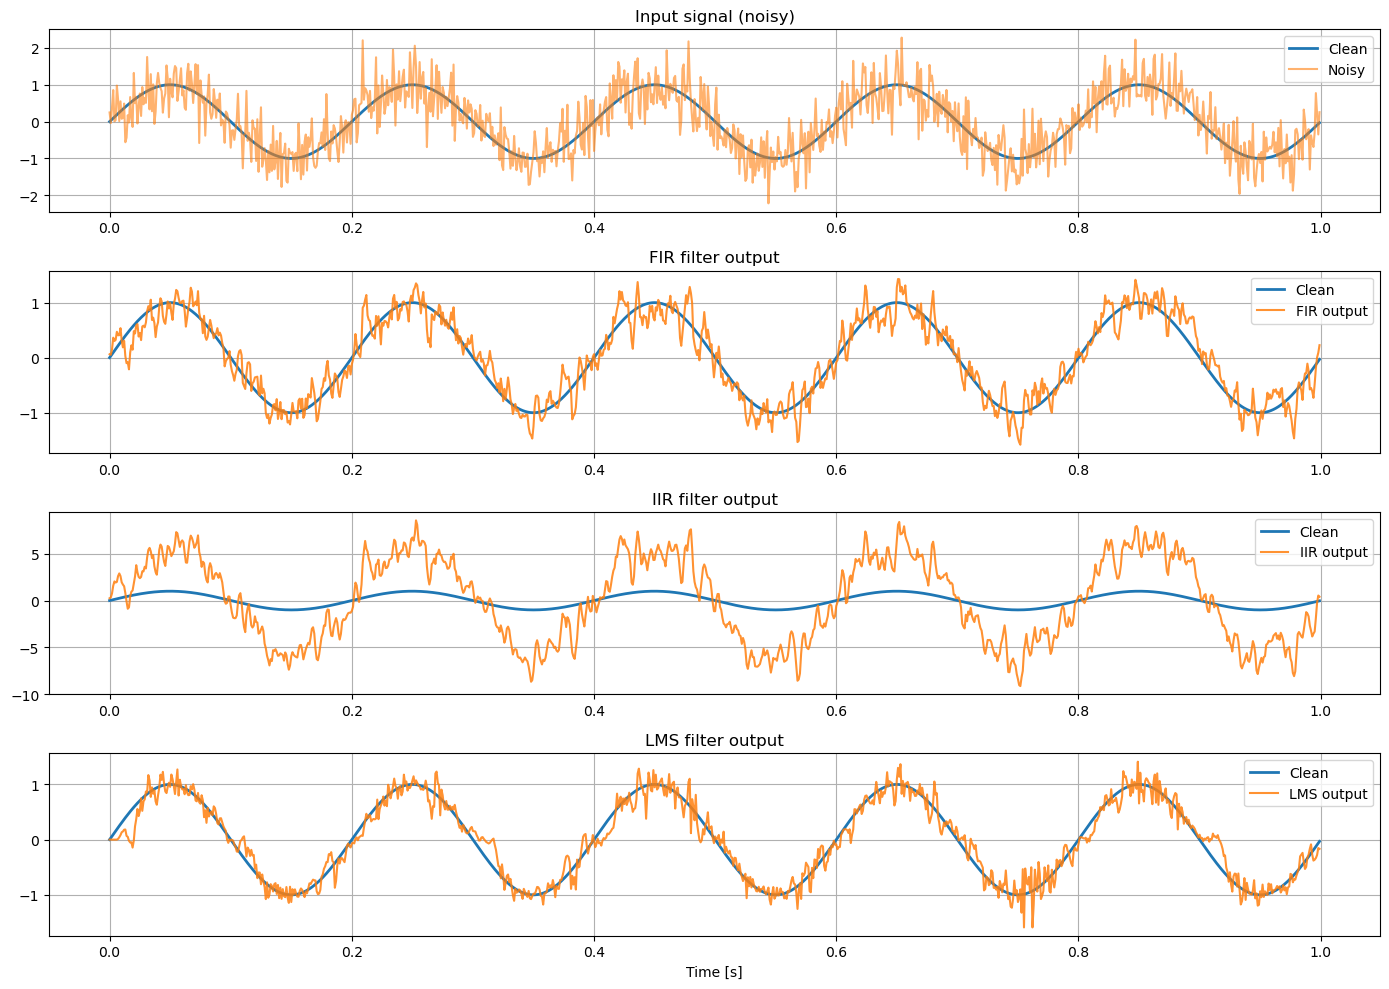

In [18]:
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t, clean, label='Clean', linewidth=2)
plt.plot(t, noisy, label='Noisy', alpha=0.6)
plt.title('Input signal (noisy)')
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t, clean, label='Clean', linewidth=2)
plt.plot(t, y_fir, label='FIR output', alpha=0.85)
plt.title('FIR filter output')
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t, clean, label='Clean', linewidth=2)
plt.plot(t, y_iir, label='IIR output', alpha=0.85)
plt.title('IIR filter output')
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(t, clean, label='Clean', linewidth=2)
plt.plot(t, y_lms, label='LMS output', alpha=0.85)
plt.title('LMS filter output')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
